# Imports

In [15]:
# Cell 1 - installs + clone
!pip install --quiet torch torchvision jax jaxlib keras_sig numpy matplotlib scipy pytorch-minimize
!git clone https://github.com/CharliePyle4/BSK_ODE.git /content/BSK_ODE 2>/dev/null || git -C /content/BSK_ODE pull

# Cell 2 - import
import sys
sys.path.insert(0, '/content/BSK_ODE')
from bsk_ode.Kuramoto_System import *
print("Using device:", active_device, "torch", torch.__version__)



Already up to date.
Using device: cuda torch 2.11.0+cu128


## Kuramoto Model



### Standard Model

$$
\frac{d\theta_i}{dt} = \omega_i + \frac{1}{N}\sum_{j=1}^{N} K_{ij} \sin(\theta_j - \theta_i), \qquad i = 1, \ldots, N
$$

### Fractional Gaussian Noise Model

If we introduce a standard uniform coupling constant $K$, and replace the white noise term by a fractional Gaussian noise term $\eta_i^H(t)$ for each oscillator, we obtain the system
$$
\frac{d\theta_i}{dt} = \omega_i + \sigma_i \eta_i^H(t) + \frac{K}{N}\sum_{j=1}^{N} \sin(\theta_j - \theta_i)
$$

Equivalently, this may be written in stochastic differential form as
$$
d\theta_i(t) = \left[ \omega_i + \frac{K}{N}\sum_{j=1}^{N} \sin(\theta_j - \theta_i) \right] dt + \sigma_i dB_i^H(t), \qquad i = 1, \ldots, N
$$

where the fractional Gaussian noise is interpreted heuristically as
$$
\eta_i^H(t) := \frac{dB_i^H(t)}{dt}.
$$

### Parameters

- $\theta_i(t)$: Phase of oscillator $i$ at time $t$
- $\dot{\theta}_i = d\theta_i/dt$: Rate of change of phase
- $\omega_i$: Natural frequency of oscillator $i$
- $N$: Total number of oscillators
- $K_{ij}$: Coupling strength between oscillators $i$ and $j$
- $K$: Uniform coupling constant (simplified model, $K_{ij} = K$ for all pairs)
- $B_i^H(t)$: Fractional Brownian motion driving oscillator $i$
- $H$: Hurst parameter of the fractional Brownian motion
- $\eta_i^H(t)$: Fractional Gaussian noise associated with oscillator $i$, obtained formally as the derivative of $B_i^H(t)$
- $\sigma_i$: Noise amplitude for oscillator $i$

### Rewritten System

$$
\frac{d\theta_i}{dt} - \omega_i - \frac{K}{N}\sum_{j=1}^{N} \sin(\theta_j - \theta_i) = \sigma_i \eta_i^H(t)
$$

## Parameters and Model Setup

In [16]:
Oscillator_count = 3
Frequencies = torch.tensor(
    [-1.0, -0.3, 1.5],
    dtype=torch.float64,
    device=active_device,
)

Coupling_constant = 3.0

# fBm / FGN parameters
HURST = 0.3
FBM_SIGMA = 1
FBM_METHOD = "daviesharte"

t_start, t_end = 0.0, 1
t_points = 1000

# Initial condition
theta0 = 2.0 * math.pi * torch.rand(
    Oscillator_count,
    dtype=torch.float64,
    device=active_device,
)

# Signature parameters
SIGDEPTH = 2

# Signature normalization
normalize = True

# Kernel parameters
KERNEL_TYPE = "rbf"
rbf_sigma = 1

# Beta optimization parameters
MAX_BETA_ITER = 500
BETA_METHOD = "l-bfgs"

# Neural Network Architecture
HIDDEN_DIMS = (8, 16, 32, 16, 8)
ACTIVATION_CLS = nn.Tanh
extensions = 2
num_snapshots = 10

# Adam Training
ADAM_ITERS = 1000
ADAM_LR = 3e-4
ADAM_lambda_model = 1
ADAM_lambda_shuffle = 1e-3

# Adam LR scheduler
ADAM_USE_SCHEDULER = True
ADAM_SCHED_FACTOR = 0.5
ADAM_SCHED_PATIENCE = 250


BETA_SOLVE_EVERY = 100 # run LBFGS only every ___ Adam steps
BETA_MIN_ITERATIONS = 50 # minimum LBFGS iters early in training
BETA_RAMP_PORTION = 0.25 # fraction of Adam iters to ramp from min -> max, ramps linearly.

""" For default settings
# New: throttling + ramp-up (disable both)
BETA_SOLVE_EVERY    = 1     # solve every Adam step
BETA_MIN_ITERATIONS = BETA_MAX_ITERATIONS  # no ramp, always full iters
BETA_RAMP_PORTION   = 1.0   # or any value; has no effect when min=max
"""

' For default settings\n# New: throttling + ramp-up (disable both)\nBETA_SOLVE_EVERY    = 1     # solve every Adam step\nBETA_MIN_ITERATIONS = BETA_MAX_ITERATIONS  # no ramp, always full iters\nBETA_RAMP_PORTION   = 1.0   # or any value; has no effect when min=max\n'

# Generate Data

max |lhs - eta|: 8.953e-13


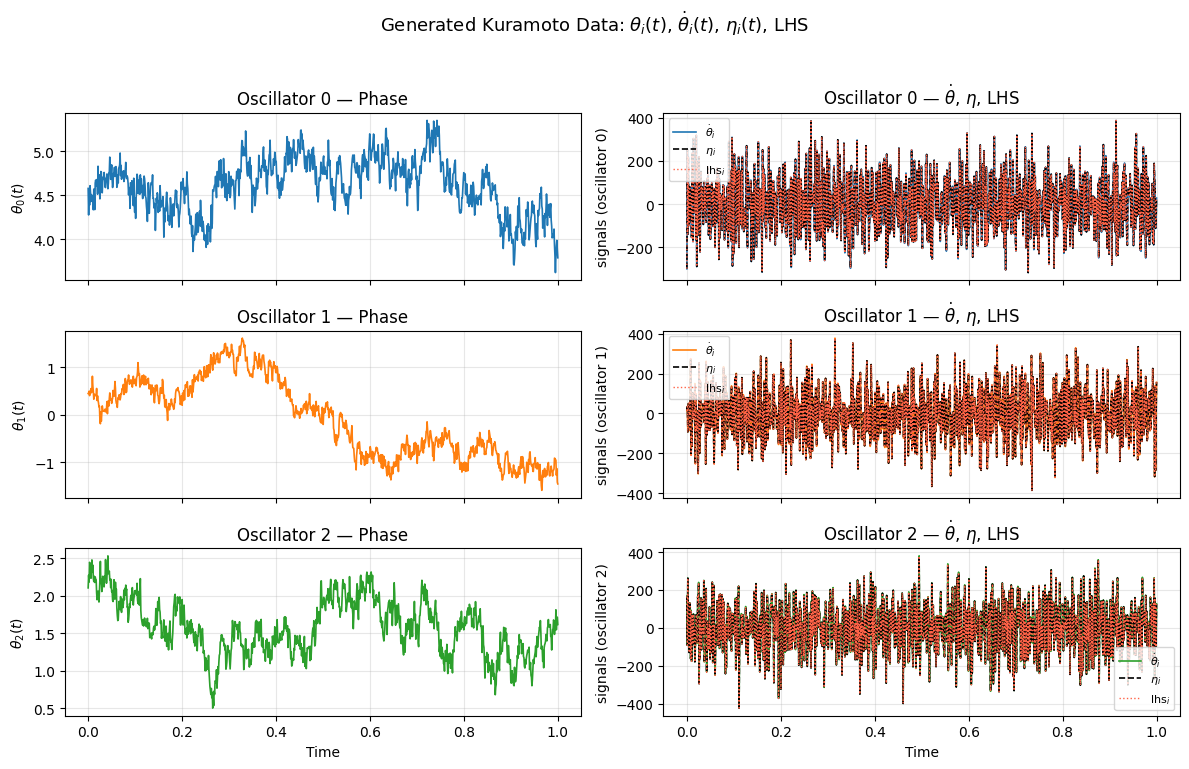

In [17]:
# ── Time grid ─────────────────────────────────────────────────
t_grid = torch.linspace(
    t_start, t_end, t_points,
    dtype=torch.float64, device=active_device,
)

# ── Generate Kuramoto quantities (fBm / FGN version) ─────────
dtheta_true, theta_true, eta_true, lhs_true = generate_kuramoto_data(
    N_paths=Oscillator_count,
    N_points=t_points,
    t0=t_start,
    T=t_end,
    K=Coupling_constant,
    omega=Frequencies,
    hurst=HURST,
    sigma=FBM_SIGMA,
    theta0=theta0,
    method=FBM_METHOD,
)

# ── Plot generated data ───────────────────────────────────────
plot_kuramoto_signals(
    Thetas=theta_true,
    DTheta=dtheta_true,
    Eta=eta_true,
    Lhs=lhs_true,
    t_grid=t_grid,
    suptitle=r'Generated Kuramoto Data: $\theta_i(t)$, $\dot{\theta}_i(t)$, $\eta_i(t)$, LHS',
)


## Run Model

In [18]:

# ── Run non-branched signature-kernel solver ──────────────────
theta_fit, dtheta_fit, lhs_fit, forcing_fit, beta = solve_signature_kernel_non_branched(
    t_grid=t_grid,
    forcing_true=eta_true,
    theta0=theta0,
    depth=SIGDEPTH,
    rbf_sigma=rbf_sigma,
    omega=Frequencies,
    K_coupling=Coupling_constant,
    kernel_type=KERNEL_TYPE,
    normalize=normalize,
    max_beta_iter=MAX_BETA_ITER,
    beta_method=BETA_METHOD,
)



# ── Run branched signature-kernel solver ──────────────────────
theta_fit_b, dtheta_fit_b, lhs_fit_b, forcing_fit_b, beta_b, X_bar_b, path_ext_b, snapshots_b, training_history = \
    solve_signature_kernel_branched(
        t_grid=t_grid,
        forcing_true=eta_true,
        theta0=theta0,
        depth=SIGDEPTH,
        rbf_sigma=rbf_sigma,
        omega=Frequencies,
        K_coupling=Coupling_constant,
        kernel_type=KERNEL_TYPE,
        normalize=normalize,
        max_beta_iter=MAX_BETA_ITER,
        beta_method=BETA_METHOD,
        hidden_dims=HIDDEN_DIMS,
        activation_cls=ACTIVATION_CLS,
        extensions=extensions,
        adam_iters=ADAM_ITERS,
        adam_lr=ADAM_LR,
        adam_lambda_model=ADAM_lambda_model,
        adam_lambda_shuffle=ADAM_lambda_shuffle,
        adam_use_scheduler=ADAM_USE_SCHEDULER,
        adam_sched_factor=ADAM_SCHED_FACTOR,
        adam_sched_patience=ADAM_SCHED_PATIENCE,
        num_snapshots=num_snapshots,
        verbose=True,
        beta_solve_every=BETA_SOLVE_EVERY,
        beta_min_iterations=BETA_MIN_ITERATIONS,
        beta_ramp_portion=BETA_RAMP_PORTION,
    )




non-branched model forcing match loss: 1.243e+00
[Adam 0001] loss=2.542e+03, model=5.492e+00, shuffle=2.536e+06
[Adam 0050] loss=1.914e+02, model=1.141e+02, shuffle=7.734e+04
[Adam 0100] loss=3.707e+01, model=3.641e-02, shuffle=3.703e+04
[Adam 0150] loss=1.724e+01, model=2.585e+00, shuffle=1.466e+04
[Adam 0200] loss=1.010e+01, model=6.630e-03, shuffle=1.010e+04
[Adam 0250] loss=6.781e+00, model=6.091e-01, shuffle=6.172e+03
[Adam 0300] loss=4.888e+00, model=1.508e-03, shuffle=4.887e+03
[Adam 0350] loss=3.759e+00, model=2.394e-01, shuffle=3.520e+03
[Adam 0400] loss=2.953e+00, model=3.966e-04, shuffle=2.953e+03
[Adam 0450] loss=2.435e+00, model=1.068e-01, shuffle=2.328e+03
[Adam 0500] loss=2.035e+00, model=1.013e-04, shuffle=2.035e+03
[Adam 0550] loss=1.742e+00, model=6.656e-02, shuffle=1.676e+03
[Adam 0600] loss=1.500e+00, model=4.254e-05, shuffle=1.500e+03
[Adam 0650] loss=1.425e+00, model=1.501e-01, shuffle=1.275e+03
[Adam 0700] loss=1.179e+00, model=1.936e-05, shuffle=1.179e+03
[Adam 

## NN training loss statistics

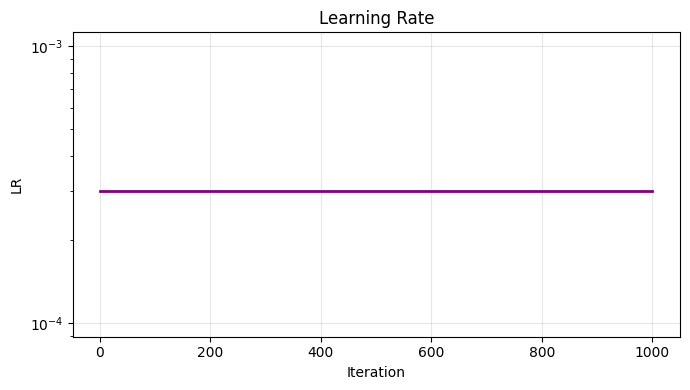

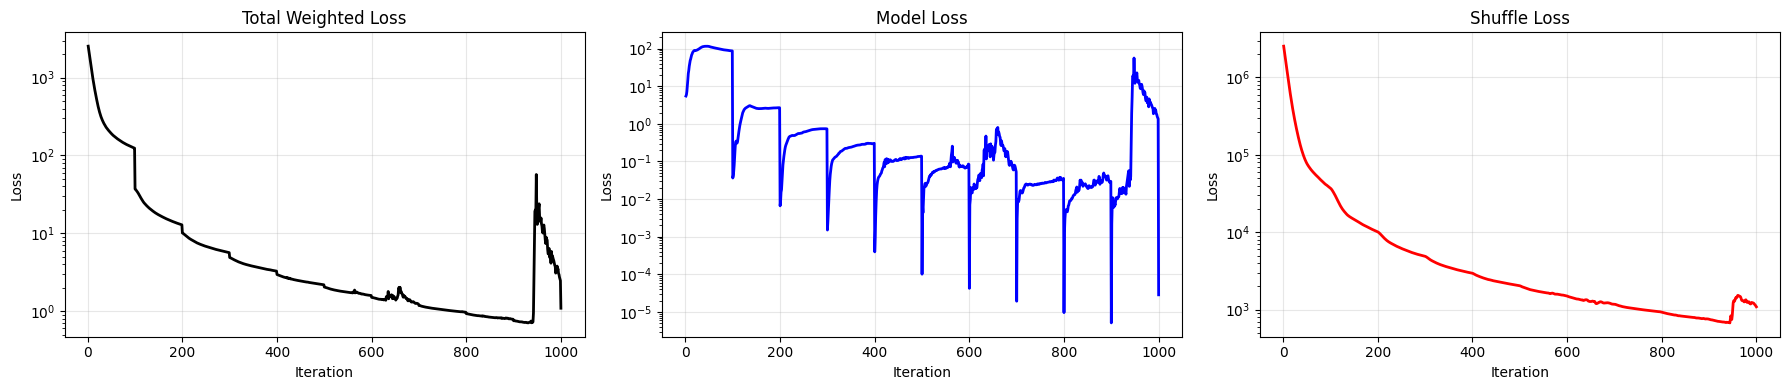

In [19]:
plot_training_history(training_history, use_log_scale=True)

## Plot results

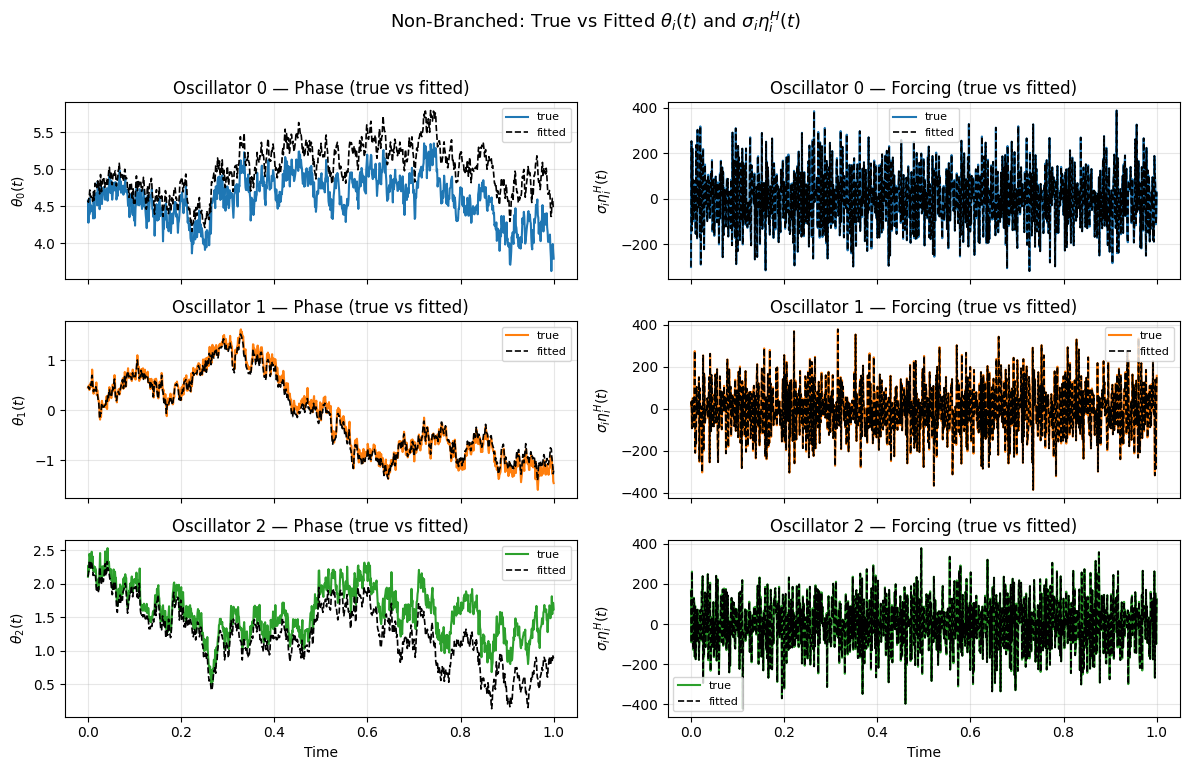

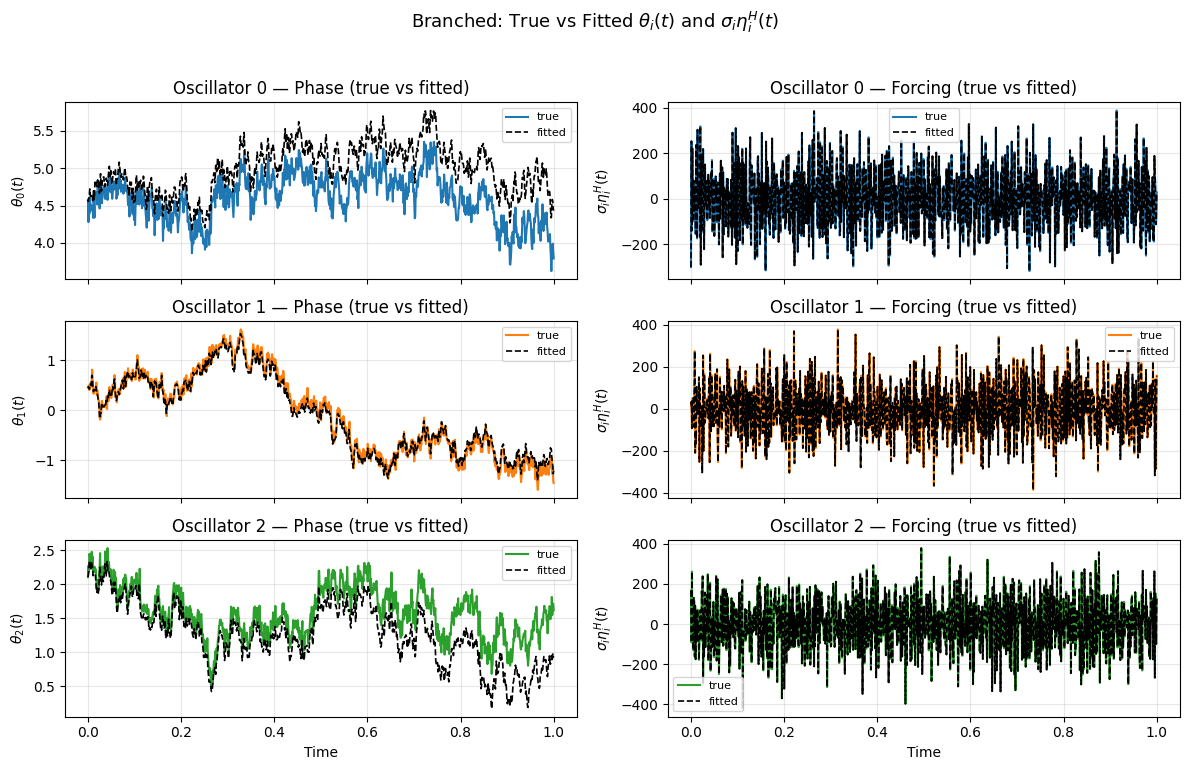

In [20]:
# ── Plot non-branched true vs fitted ─────────────────────────
plot_kuramoto_true_vs_fitted(
    Thetas_true=theta_true,
    Values_true=eta_true,
    Thetas_fit=theta_fit,
    Values_fit=forcing_fit,
    t_grid=t_grid,
    value_label=r'\sigma_i \eta_i^H(t)',
    value_title='Forcing',
    suptitle=r'Non-Branched: True vs Fitted $\theta_i(t)$ and $\sigma_i\eta_i^H(t)$',
)

# ── Plot branched true vs fitted ──────────────────────────────
plot_kuramoto_true_vs_fitted(
    Thetas_true=theta_true,
    Values_true=eta_true,
    Thetas_fit=theta_fit_b,
    Values_fit=forcing_fit_b,
    t_grid=t_grid,
    value_label=r'\sigma_i \eta_i^H(t)',
    value_title='Forcing',
    suptitle=r'Branched: True vs Fitted $\theta_i(t)$ and $\sigma_i\eta_i^H(t)$',
)

In [21]:
# ── MSE summary ───────────────────────────────────────────────
forcing_mse   = torch.mean((eta_true   - forcing_fit)   ** 2).item()
theta_mse     = torch.mean((theta_true - theta_fit)     ** 2).item()
dtheta_mse    = torch.mean((dtheta_true - dtheta_fit)   ** 2).item()

forcing_mse_b = torch.mean((eta_true   - forcing_fit_b) ** 2).item()
theta_mse_b   = torch.mean((theta_true - theta_fit_b)   ** 2).item()
dtheta_mse_b  = torch.mean((dtheta_true - dtheta_fit_b) ** 2).item()

# ── Relative errors ───────────────────────────────────────────
forcing_var   = torch.mean(eta_true    ** 2).item()
theta_var     = torch.mean(theta_true  ** 2).item()
dtheta_var    = torch.mean(dtheta_true ** 2).item()

forcing_rel   = forcing_mse   / forcing_var
theta_rel     = theta_mse     / theta_var
dtheta_rel    = dtheta_mse    / dtheta_var

forcing_rel_b = forcing_mse_b / forcing_var
theta_rel_b   = theta_mse_b   / theta_var
dtheta_rel_b  = dtheta_mse_b  / dtheta_var

# ── Branched improvement over non-branched ────────────────────
forcing_improvement = (forcing_mse - forcing_mse_b) / forcing_mse * 100
theta_improvement   = (theta_mse   - theta_mse_b)   / theta_mse   * 100
dtheta_improvement  = (dtheta_mse  - dtheta_mse_b)  / dtheta_mse  * 100

# ── Print results ─────────────────────────────────────────────
print(f"{'':30s} {'Non-Branched':>15s} {'Branched':>15s} {'Improvement':>15s}")
print("-" * 78)
print(f"{'Forcing MSE':30s} {forcing_mse:>15.6e} {forcing_mse_b:>15.6e} {forcing_improvement:>14.2f}%")
print(f"{'Forcing Relative MSE':30s} {forcing_rel:>15.6e} {forcing_rel_b:>15.6e}")
print("-" * 78)
print(f"{'DTheta MSE':30s} {dtheta_mse:>15.6e} {dtheta_mse_b:>15.6e} {dtheta_improvement:>14.2f}%")
print(f"{'DTheta Relative MSE':30s} {dtheta_rel:>15.6e} {dtheta_rel_b:>15.6e}")
print("-" * 78)
print(f"{'Theta MSE':30s} {theta_mse:>15.6e} {theta_mse_b:>15.6e} {theta_improvement:>14.2f}%")
print(f"{'Theta Relative MSE':30s} {theta_rel:>15.6e} {theta_rel_b:>15.6e}")

                                  Non-Branched        Branched     Improvement
------------------------------------------------------------------------------
Forcing MSE                       1.243373e+00    8.144438e-06         100.00%
Forcing Relative MSE              7.684016e-05    5.033242e-10
------------------------------------------------------------------------------
DTheta MSE                        1.647092e+00    3.756546e-01          77.19%
DTheta Relative MSE               1.018599e-04    2.323133e-05
------------------------------------------------------------------------------
Theta MSE                         1.134404e-01    1.022961e-01           9.82%
Theta Relative MSE                1.381621e-02    1.245892e-02
